# Classification through fine-tuning

In [1]:
! cd .. && pip install --quiet -e . && cd notebooks && pip list | grep suplat

  DEPRECATION: Setting PIP_CONSTRAINT will not affect build constraints in the future, pip 26.2 will enforce this behaviour change. A possible replacement is to specify build constraints using --build-constraint or PIP_BUILD_CONSTRAINT. To disable this warning without any build constraints set --use-feature=build-constraint or PIP_USE_FEATURE="build-constraint".
suplat                     0.1.0                         /capstor/store/cscs/ska/sk030/projectG_supervised_latent_radiogals


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset

from suplat.data.data_samplers import BYOLSupDataset, UnlabelledBYOLDataset, weights_ponderate, weights_closest
from suplat.models.byol_models import BYOLEfficientNetB0
from suplat.data.augmentations import get_augmentation

if torch.cuda.is_available():
    print("using gpu")
    device = torch.device('cuda')
    torch.cuda.set_device(0)
    use_cuda = torch.cuda.is_available()
else:
    print("using cpu")
    
%pylab inline

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using gpu
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
byol_path = "../outputs/run_run_mlp_sw0.5_fl0.5_20260608_1713/byol_model_best.pt"
checkpoint = torch.load(byol_path, map_location="cpu", weights_only=True)
print(checkpoint["config"])

{'model_type': 'efficientnet-b0', 'batch_size': 256, 'learning_rate': 0.0003, 'num_epochs': 400, 'warmup_epochs': 0, 'grad_clip': None, 'ema_decay': 0.99, 'projection_dim': 128, 'hidden_dim': 4096, 'encoder_dim': 1280, 'weighting': 'ponderate', 'f_label': 0.5, 'data_seed': 42, 'supervision_weight': 0.5, 'supervision_weight_schedule': 'constant', 'projector': 'mlp', 'label_type': 'full'}


In [3]:
from torch.utils.data import Dataset
from scipy.spatial.distance import cdist

class BYOLSupDataset(Dataset):
    """
    Dataset for BYOL with supervised pairing based on label similarity.
    Returns :
    - img: original image
    - img_transformed: transformed image (positive pair)
    - img_friend: image from similar (or close) class
    - mdist: Manhattan distance between the labels img and img_friend
    """
    def __init__(self,
                 tags_data,
                 img_data,
                 transform=None,
                 friend_transform=None,
                 weightfunc=weights_closest,
                 p_pair_from_class=0.5):
        self.all_labels = tags_data
        self.img_data = img_data
        self.transform = transform
        self.friend_transform = friend_transform
        self.weightfunc = weightfunc
        self.p_pair_from_class = p_pair_from_class
        # build the distance matrix once for efficiency
        self.label_distances = cdist(self.all_labels.values, self.all_labels.values, metric="cityblock")
    
    def __len__(self):
        return self.all_labels.shape[0]
    
    def __getitem__(self, idx):
        # Fetch numpy array from storage
        img = self.img_data[idx]
        label_vec = self.all_labels.iloc[idx, :].values.reshape(1, -1)
        
        # Sample a friend image from similar class, using the precomputed distance matrix
        all_tags_nofid = self.all_labels.drop(index=idx)
        pi = self.label_distances[idx, all_tags_nofid.index].reshape(1, -1)
        weights = self.weightfunc(pi)
        sample = np.random.choice(all_tags_nofid.shape[0], p=weights)
        idx_friend = all_tags_nofid.index[sample]
        mdist = pi[0, sample]
        img_friend = self.img_data[idx_friend]
        
        # Convert numpy arrays to tensors BEFORE transforms
        img = torch.from_numpy(img).unsqueeze(0).float()  # Shape: (1, H, W)
        img_friend = torch.from_numpy(img_friend).unsqueeze(0).float()
        
        # Apply transforms to tensors
        if self.transform:
            img_transformed = self.transform(img)
        if self.friend_transform:
            img_friend = self.friend_transform(img_friend)
        
        return img, img_transformed, img_friend, torch.tensor(mdist, dtype=torch.float32), \
               torch.tensor(idx, dtype=torch.float32), torch.tensor(idx_friend, dtype=torch.float32), \
               label_vec, self.all_labels.iloc[idx_friend, :].values.reshape(1, -1)


class UnlabelledBYOLDataset(Dataset):
    def __init__(self, img_data, transform=None):
        self.img_data = img_data
        self.transform = transform

    def __len__(self):
        return len(self.img_data)

    def __getitem__(self, idx):
        img = self.img_data[idx]
        img = torch.from_numpy(img).unsqueeze(0).float()
        img_aug = self.transform(img) if self.transform else img.clone()
        return img, img_aug, None, torch.tensor(0.0, dtype=torch.float32),\
               torch.tensor(idx, dtype=torch.float32), torch.tensor(idx, dtype=torch.float32),\
               None, None
        
               

In [19]:
images = np.load("../data/preprocessed/lotss/images_filtered.npy").astype(np.float32)/255
labels = np.load("../data/preprocessed/lotss/labels_filtered.npy")

print(labels.shape)
DATA_SEED = checkpoint["config"]['data_seed']
F_LABEL = checkpoint["config"]['f_label']
TRAIN_RATIO, TEST_RATIO = 0.70, 0.30
all_idx = np.arange(len(images))
train_idx, test_idx = train_test_split(all_idx, test_size=TEST_RATIO, random_state=DATA_SEED)
train_images, train_labels = images[train_idx], labels[train_idx]
test_images  = images[test_idx]
test_labels  = labels[test_idx]

# Labelled subset via stratified sampling
if F_LABEL == 0.0:
    labelled_mask = np.zeros(len(train_idx), dtype=bool)
elif F_LABEL >= 1.0:
    labelled_mask = np.ones(len(train_idx), dtype=bool)
else:
    strat_key = np.argmax(train_labels[:, :min(5, train_labels.shape[1])], axis=1)
    n_lab = max(2, int(round(F_LABEL * len(train_idx))))
    try:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=n_lab, random_state=DATA_SEED)
        lab_rel, _ = next(sss.split(train_images, strat_key))
    except ValueError:
        print("Stratification failed, falling back to random selection")
        lab_rel = np.random.choice(len(train_idx), n_lab, replace=False)
    labelled_mask = np.zeros(len(train_idx), dtype=bool)
    labelled_mask[lab_rel] = True

def byol_collate_fn(batch):
    x1     = torch.stack([b[0] for b in batch])
    x1_aug = torch.stack([b[1] for b in batch])
    is_labelled = torch.tensor([b[2] is not None for b in batch], dtype=torch.bool)
    if is_labelled.any():
        dummy = torch.zeros_like(batch[0][0])
        x2_friend = torch.stack([b[2] if b[2] is not None else dummy for b in batch])
    else:
        x2_friend = None
    mdists = torch.stack([b[3] for b in batch])
    x1_idx = torch.stack([b[4] for b in batch])
    x2_idx = torch.stack([b[5] for b in batch])
    return x1, x1_aug, x2_friend, is_labelled, mdists, x1_idx, x2_idx

labelled_images = train_images[labelled_mask]
labelled_labels = train_labels[labelled_mask]
unlabelled_images = train_images[~labelled_mask]
labelled_train_idx = train_idx[labelled_mask]

byol_strong_aug = get_augmentation("standard")

lab_df = pd.DataFrame(labelled_labels)
unlab_ds = UnlabelledBYOLDataset(unlabelled_images, transform=byol_strong_aug)

lab_df = pd.DataFrame(labelled_labels)
lab_ds = BYOLSupDataset(tags_data=lab_df, img_data=labelled_images,
                         transform=byol_strong_aug, friend_transform=byol_strong_aug,
                         weightfunc=weights_ponderate, p_pair_from_class=0.5)
_train_combined = ConcatDataset([lab_ds, unlab_ds])

test_unlab_ds = UnlabelledBYOLDataset(test_images, transform=byol_strong_aug)
_train_combined = ConcatDataset([_train_combined, test_unlab_ds])

train_loader = DataLoader(_train_combined, batch_size=256, shuffle=True, drop_last=True,
                          num_workers=1, pin_memory=use_cuda,
                          collate_fn=byol_collate_fn)

labelled_train_loader = DataLoader(lab_ds, batch_size=256, shuffle=True, drop_last=True,
                          num_workers=1, pin_memory=use_cuda)

test_lab_ds = BYOLSupDataset(tags_data=pd.DataFrame(test_labels), img_data=test_images,
                         transform=byol_strong_aug, friend_transform=byol_strong_aug,
                         weightfunc=weights_ponderate, p_pair_from_class=0.5)
labelled_test_loader = DataLoader(test_lab_ds, batch_size=256, shuffle=True, drop_last=True,
                                  num_workers=1, pin_memory=use_cuda)

(7596, 20)


In [5]:
checkpoint = torch.load(byol_path, map_location="cpu", weights_only=True)

model = BYOLEfficientNetB0(
    projection_dim=checkpoint["config"]['projection_dim'],
    hidden_dim=checkpoint["config"]['hidden_dim'],
    bn_momentum=0.1,
    feature_compression_mode=checkpoint["config"]['projector'],
    dropout_rate=0.2,
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /users/ncerardi/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 93.5MB/s]


torch.Size([256]) torch.Size([256, 1, 89, 89]) (89, 89)


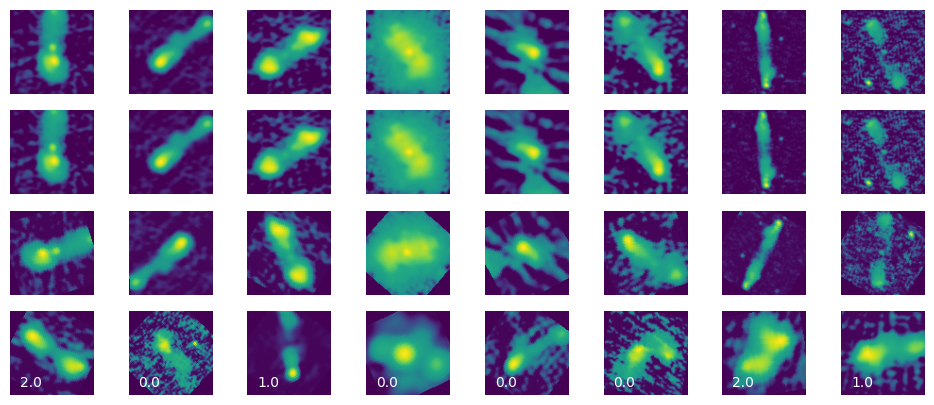

In [6]:
x1, x1_aug, x2_friend, is_labelled, mdist, x1_idx, x2_idx = next(iter(train_loader))
print(is_labelled.shape, x1.shape, labelled_images[int(x1_idx[is_labelled][0].item())].shape)
figure(figsize=(12,5))
for i in range(8):
    subplot(4, 8, 1+i)
    imshow(labelled_images[int(x1_idx[is_labelled][i].item())])
    axis('off')
    subplot(4, 8, 1+8+i)
    imshow(x1[is_labelled][i,0,:])
    axis('off')
    subplot(4, 8, 1+16+i)
    imshow(x1_aug[is_labelled][i,0,:])
    axis('off')
    subplot(4, 8, 1+24+i)
    imshow(x2_friend[is_labelled][i,0,:])
    axis('off')
    text(10,80,mdist[is_labelled][i].item(), c='w')

[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


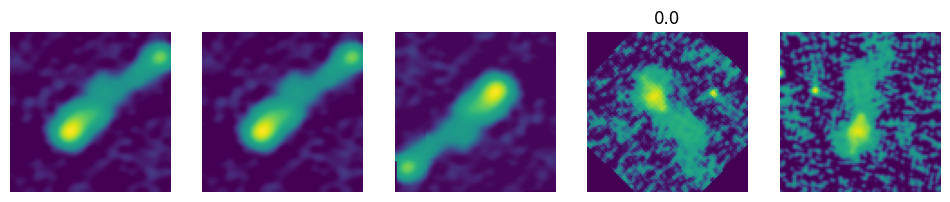

In [7]:
i=1
figure(figsize=(12,5))
subplot(1, 5, 1)
imshow(labelled_images[int(x1_idx[is_labelled][i].item())])
axis('off')
subplot(1, 5, 2)
imshow(x1[is_labelled][i,0,:])
axis('off')
subplot(1, 5, 3)
imshow(x1_aug[is_labelled][i,0,:])
axis('off')
subplot(1, 5, 4)
imshow(x2_friend[is_labelled][i,0,:])
axis('off')
title(mdist[is_labelled][i].item())
subplot(1, 5, 5)
imshow(labelled_images[int(x2_idx[is_labelled][i].item())])
axis('off')
print(lab_df.iloc[int(x1_idx[is_labelled][i].item()),:].values)
print(lab_df.iloc[int(x2_idx[is_labelled][i].item()),:].values)

(array([35., 19., 17., 11.,  4.,  4.,  1.,  0.,  0.,  0.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

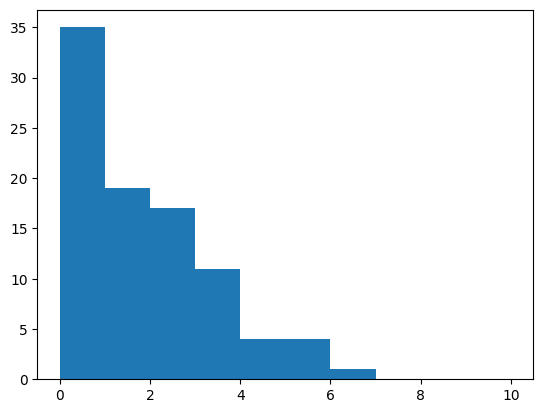

In [8]:
plt.hist(mdist[is_labelled], bins=np.arange(0,11))

In [9]:
import torch
import torch.nn as nn

class BYOLFineTuner(nn.Module):
    def __init__(self, byol_model, num_classes=21, freeze_until_feature_idx=0):
        super().__init__()

        self.encoder = byol_model.online_encoder
        self.projector = byol_model.online_projector

        # BYOL projection_dim = 128 in your case
        self.classifier = nn.Linear(128, num_classes)

        self.freeze_encoder_until(freeze_until_feature_idx)

    def freeze_encoder_until(self, freeze_until_feature_idx):
        """
        freeze_until_feature_idx:
            0 = train all encoder
            5 = freeze encoder.features[0] ... encoder.features[4]
            9 = freeze all EfficientNet features
        """

        # First train everything
        for p in self.encoder.parameters():
            p.requires_grad = True
        for p in self.projector.parameters():
            p.requires_grad = True
        for p in self.classifier.parameters():
            p.requires_grad = True

        # Then freeze early EfficientNet blocks
        for idx, block in enumerate(self.encoder.features):
            if idx < freeze_until_feature_idx:
                for p in block.parameters():
                    p.requires_grad = False

    def forward(self, x):
        z = self.encoder(x)
        z = self.projector(z)
        logits = self.classifier(z)
        return logits

In [27]:
num_classes = 20  # change this

finetune_model = BYOLFineTuner(
    byol_model=model,
    num_classes=num_classes,
    freeze_until_feature_idx=0,
)

finetune_model = finetune_model.to(device)

In [28]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, finetune_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)

criterion = nn.BCEWithLogitsLoss()

In [ ]:
import torch
import matplotlib.pyplot as plt

num_epochs = 20

train_losses = []
test_losses = []

for epoch in range(num_epochs):

    # ======================
    # TRAIN
    # ======================
    finetune_model.train()

    train_loss = 0.0
    train_batches = 0

    for batch in labelled_train_loader:
        x1, x1_aug, x2_friend, mdist, x1_idx, x2_idx, x1_lab, x2_lab = batch

        x1_aug = x1_aug.float().to(device)
        y = x1_lab.float().to(device)

        if y.ndim == 3 and y.shape[1] == 1:
            y = y.squeeze(1)

        optimizer.zero_grad()

        logits = finetune_model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_batches += 1

    avg_train_loss = train_loss / train_batches
    train_losses.append(avg_train_loss)

    # ======================
    # TEST
    # ======================
    finetune_model.eval()

    test_loss = 0.0
    test_batches = 0

    with torch.no_grad():
        for batch in labelled_test_loader:
            x1, x1_aug, x2_friend, mdist, x1_idx, x2_idx, x1_lab, x2_lab = batch

            x1_aug = x1_aug.float().to(device)
            y = x1_lab.float().to(device)

            if y.ndim == 3 and y.shape[1] == 1:
                y = y.squeeze(1)

            logits = finetune_model(x)
            loss = criterion(logits, y)

            test_loss += loss.item()
            test_batches += 1

    avg_test_loss = test_loss / test_batches
    test_losses.append(avg_test_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train: {avg_train_loss:.4f} "
        f"| Test: {avg_test_loss:.4f}"
    )

Epoch [1/20] | Train: 1.1399 | Test: 0.8860
Epoch [2/20] | Train: 0.8014 | Test: 0.7239
Epoch [3/20] | Train: 0.6558 | Test: 0.6309
Epoch [4/20] | Train: 0.5833 | Test: 0.5465
Epoch [5/20] | Train: 0.5176 | Test: 0.4729
Epoch [6/20] | Train: 0.4531 | Test: 0.4126
Epoch [7/20] | Train: 0.3923 | Test: 0.3608
Epoch [8/20] | Train: 0.3433 | Test: 0.3165
Epoch [9/20] | Train: 0.3078 | Test: 0.2896
Epoch [10/20] | Train: 0.2845 | Test: 0.2715
Epoch [11/20] | Train: 0.2706 | Test: 0.2612
Epoch [12/20] | Train: 0.2623 | Test: 0.2585
Epoch [13/20] | Train: 0.2582 | Test: 0.2553
Epoch [14/20] | Train: 0.2554 | Test: 0.2535
Epoch [15/20] | Train: 0.2532 | Test: 0.2500
Epoch [16/20] | Train: 0.2535 | Test: 0.2496
Epoch [17/20] | Train: 0.2521 | Test: 0.2503
Epoch [18/20] | Train: 0.2509 | Test: 0.2519
Epoch [19/20] | Train: 0.2522 | Test: 0.2513
Epoch [20/20] | Train: 0.2510 | Test: 0.2490


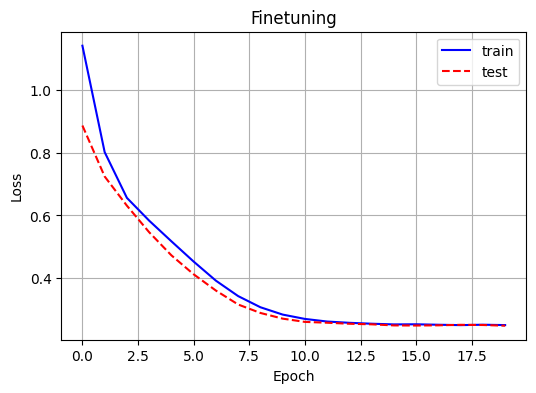

In [30]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, 'b-', label="train")
plt.plot(test_losses, 'r--', label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Finetuning")
plt.legend()
plt.grid(True)
plt.show()

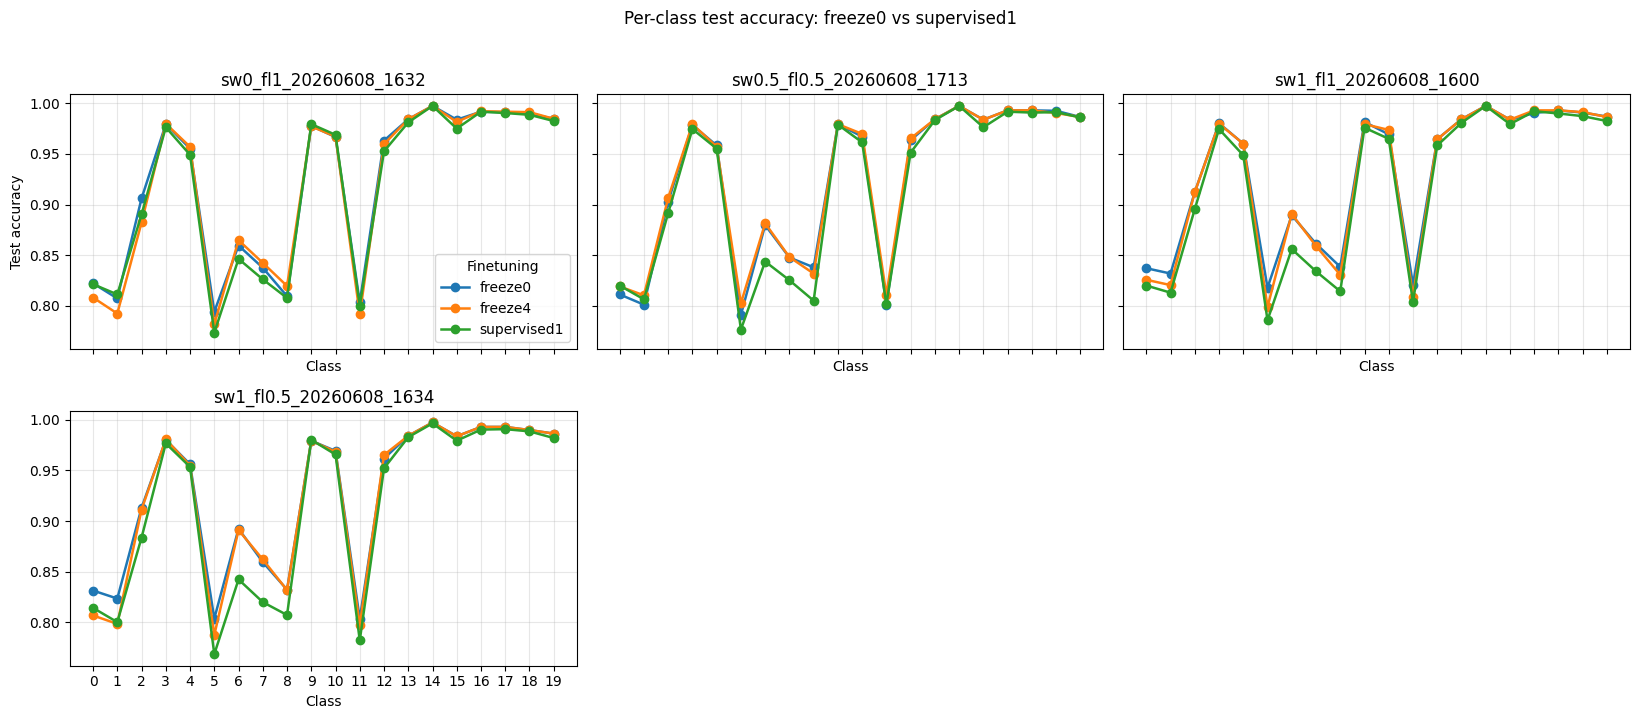

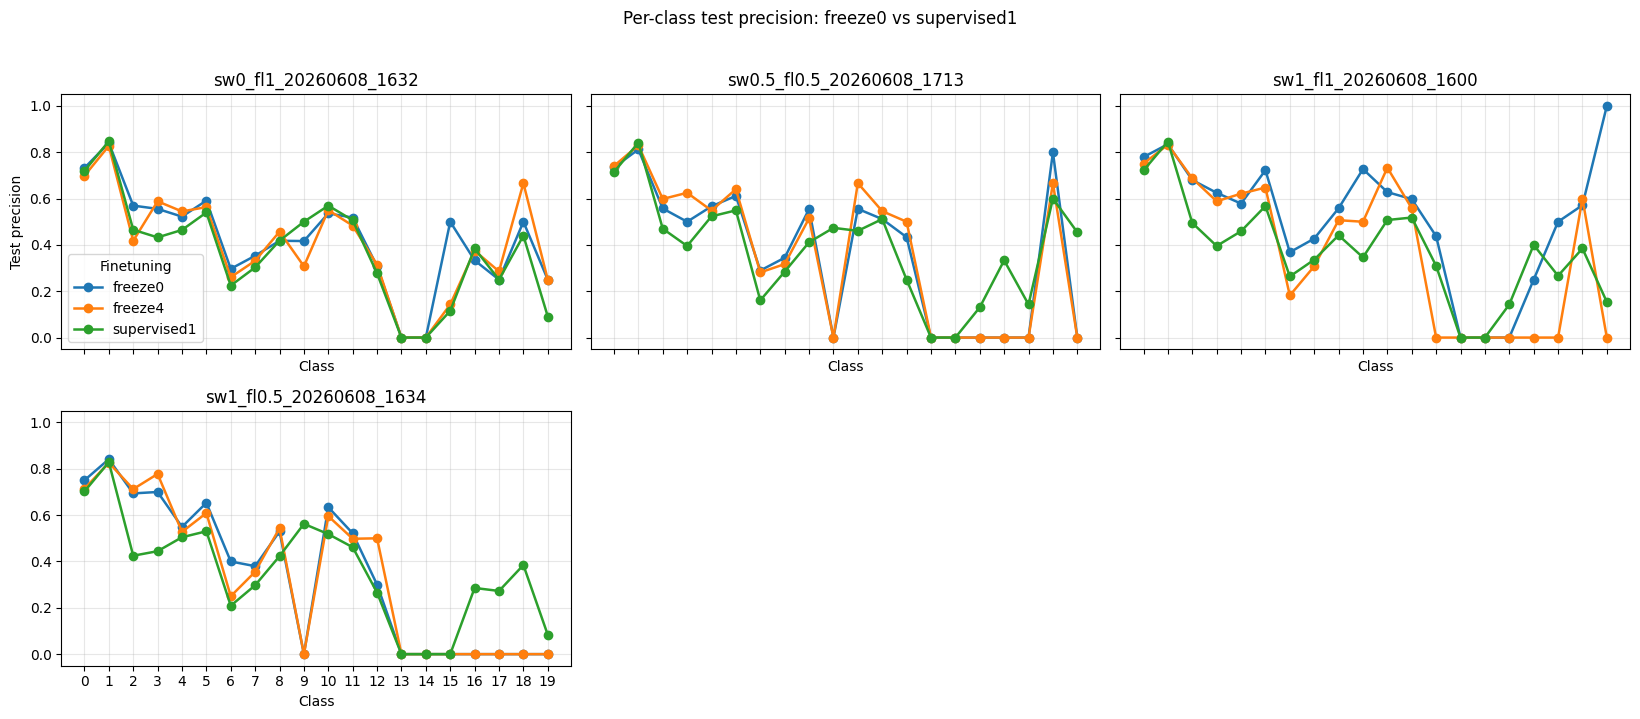

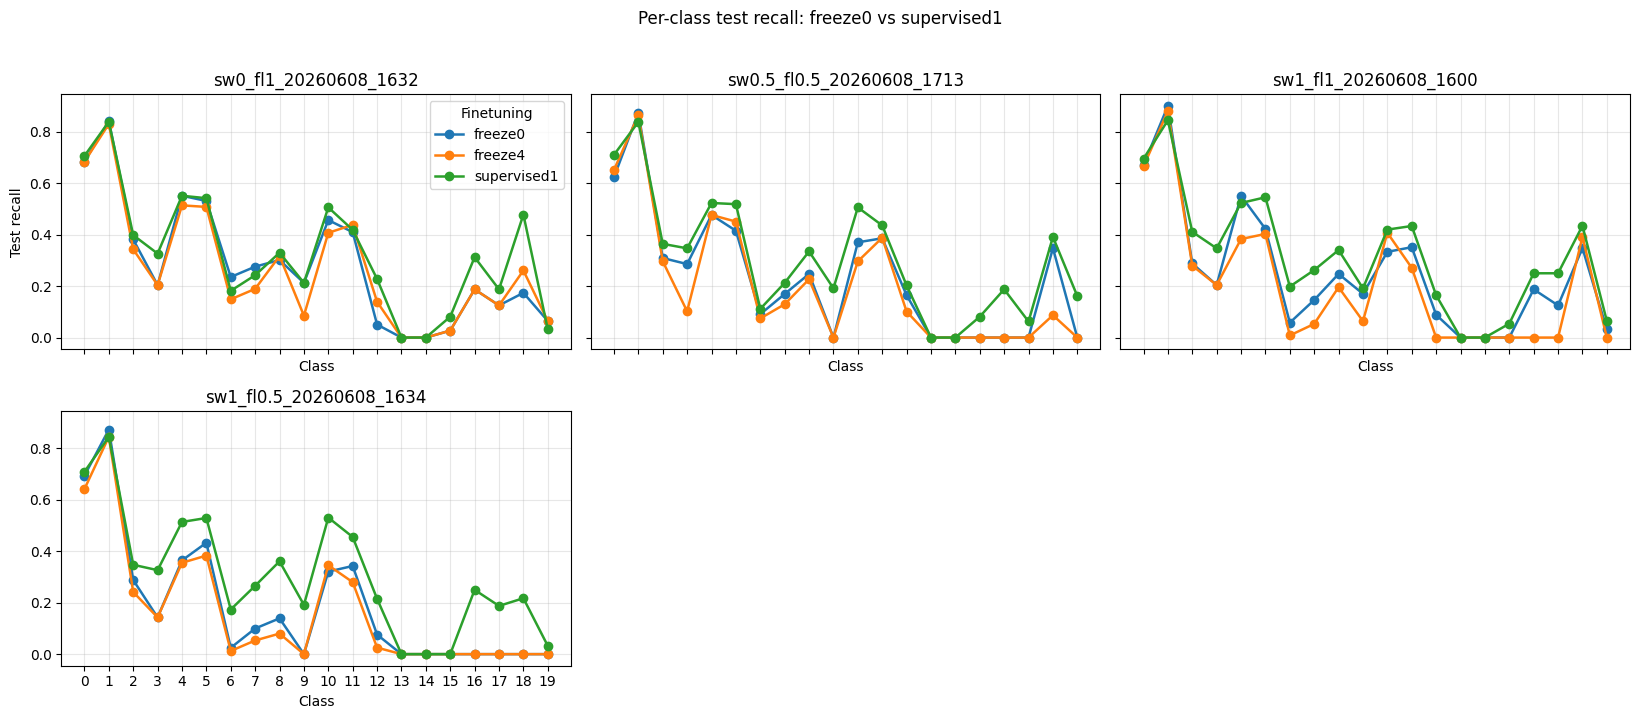

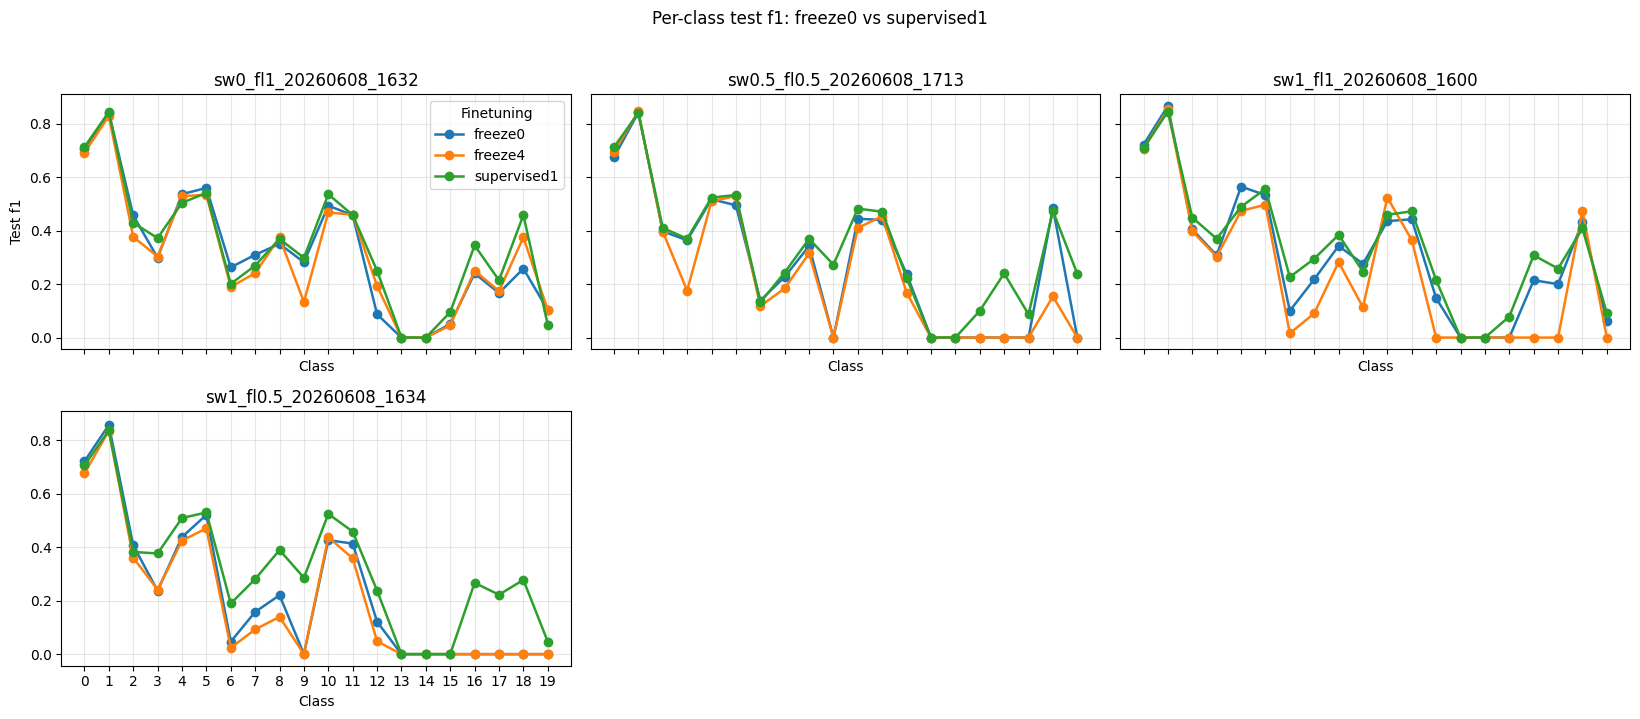

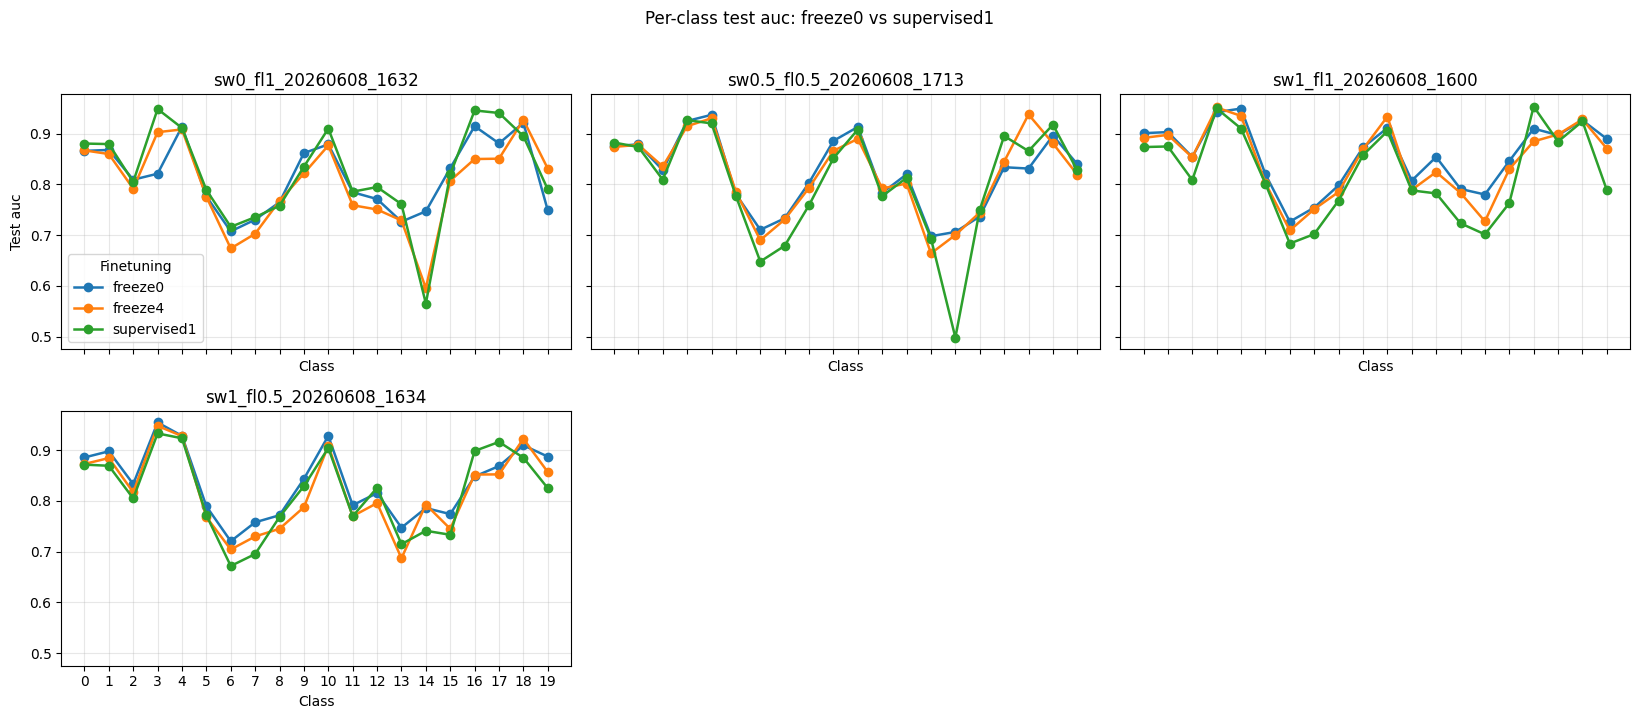

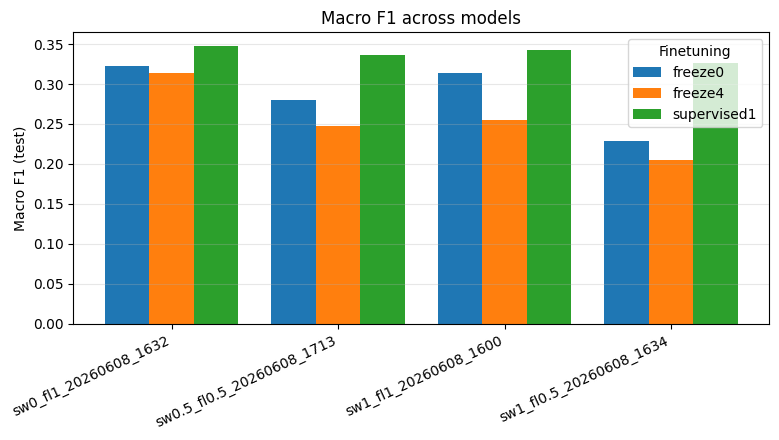

In [6]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

model_paths = [
    "../outputs/run_run_mlp_sw0_fl1_20260608_1632/",
    "../outputs/run_run_mlp_sw0.5_fl0.5_20260608_1713/",
    "../outputs/run_run_mlp_sw1_fl1_20260608_1600/",
    "../outputs/run_run_mlp_sw1_fl0.5_20260608_1634/",
]

finetune_types = [
    "finetuning_freeze0",
    "finetuning_freeze4",
    "finetuning_supervised1",
]

per_class_metrics = ["accuracy", "precision", "recall", "f1", "auc"]

def _nested_get(obj, path):
    cur = obj
    for key in path:
        if isinstance(cur, dict) and key in cur:
            cur = cur[key]
        else:
            return None
    return cur


def _extract_per_class_metric(metrics, metric_name):
    candidates = [
        (metric_name, "test"),
        (metric_name,),
        ("per_class", metric_name),
        ("test", metric_name),
        ("classification", metric_name, "test"),
    ]
    value = None
    for path in candidates:
        value = _nested_get(metrics, path)
        if value is not None:
            break

    if value is None:
        return None

    if isinstance(value, dict):
        for k in ("per_class", "values", "by_class", "test"):
            if k in value:
                value = value[k]
                break

    arr = np.asarray(value, dtype=np.float32)
    if arr.ndim == 0:
        return None
    return arr.reshape(-1)


def _extract_macro_f1(metrics):
    candidates = [
        ("macro_f1", "test"),
        ("macro_f1",),
        ("f1_macro", "test"),
        ("f1_macro",),
        ("macro", "f1"),
    ]
    value = None
    for path in candidates:
        value = _nested_get(metrics, path)
        if value is not None:
            break

    if value is None:
        return None

    if isinstance(value, dict):
        for k in ("value", "score", "test"):
            if k in value:
                value = value[k]
                break

    arr = np.asarray(value, dtype=np.float32)
    if arr.ndim == 0:
        return float(arr)
    if arr.size == 0:
        return None
    return float(arr.mean())


metrics_by_type = {metric: {ftype: {} for ftype in finetune_types} for metric in per_class_metrics}
macro_f1_results = {ftype: {} for ftype in finetune_types}

for ftype in finetune_types:
    for model_path in model_paths:
        metrics_path = Path(model_path) / "data" / "classifiers" / ftype / "finetuning_metrics.json"
        if not os.path.exists(metrics_path):
            continue

        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        for metric_name in per_class_metrics:
            per_class_vals = _extract_per_class_metric(metrics, metric_name)
            if per_class_vals is not None:
                metrics_by_type[metric_name][ftype][model_path] = per_class_vals

        macro_val = _extract_macro_f1(metrics)
        if macro_val is not None:
            macro_f1_results[ftype][model_path] = macro_val

for metric_name in per_class_metrics:
    plot_model_paths = [
        model_path
        for model_path in model_paths
        if all(model_path in metrics_by_type[metric_name][ftype] for ftype in finetune_types)
    ]

    if not plot_model_paths:
        print(f"Skipping {metric_name}: no complete set across finetuning types.")
        continue

    num_classes = len(metrics_by_type[metric_name][finetune_types[0]][plot_model_paths[0]])
    class_idx = np.arange(num_classes)
    ncols = min(3, len(plot_model_paths))
    nrows = int(np.ceil(len(plot_model_paths) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5.5 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, model_path in zip(axes, plot_model_paths):
        model_name = Path(model_path.rstrip("/")).name.replace("run_run_mlp_", "")
        for ftype in finetune_types:
            label = ftype.replace("finetuning_", "")
            ax.plot(
                class_idx,
                metrics_by_type[metric_name][ftype][model_path],
                marker="o",
                linewidth=1.8,
                label=label,
            )
        ax.set_title(model_name)
        ax.set_xticks(class_idx)
        ax.set_xlabel("Class")
        ax.grid(True, alpha=0.3)

    for ax in axes[len(plot_model_paths):]:
        ax.axis("off")

    axes[0].set_ylabel(f"Test {metric_name}")
    axes[0].legend(title="Finetuning")
    fig.suptitle(f"Per-class test {metric_name}: freeze0 vs supervised1", y=1.02)
    fig.tight_layout()
    plt.show()

macro_plot_model_paths = [
    model_path
    for model_path in model_paths
    if all(model_path in macro_f1_results[ftype] for ftype in finetune_types)
]

if not macro_plot_model_paths:
    print("Skipping macro_f1 plot: no complete set across finetuning types.")
else:
    x = np.arange(len(macro_plot_model_paths))
    width = 0.8 / len(finetune_types)

    plt.figure(figsize=(max(8, 1.8 * len(macro_plot_model_paths)), 4.5))
    for i, ftype in enumerate(finetune_types):
        label = ftype.replace("finetuning_", "")
        values = [macro_f1_results[ftype][model_path] for model_path in macro_plot_model_paths]
        offset = (i - (len(finetune_types) - 1) / 2) * width
        plt.bar(x + offset, values, width=width, label=label)

    model_labels = [Path(mp.rstrip("/")).name.replace("run_run_mlp_", "") for mp in macro_plot_model_paths]
    plt.xticks(x, model_labels, rotation=25, ha="right")
    plt.ylabel("Macro F1 (test)")
    plt.title("Macro F1 across models")
    plt.grid(axis="y", alpha=0.3)
    plt.legend(title="Finetuning")
    plt.tight_layout()
    plt.show()